### 데이터를 가지고 시각화하는 작업을 진행

- matplotlib : 2d 또는 3d로 데이터를 시각화하는 라이브러리
- seaborn : matplotlib에서는 예쁘게 안보여서 예쁘게 만들어주는

In [1]:
 # 도구를 불러와보자

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [4]:
df = pd.read_csv('Pokemon.csv')


###  기본 그래프 생성

- 데이터를 화면에 그리는 함수들
- plt.plot() : 선 그래프 / (추세) 시계열 데이터 또는 연속적인 변화를 볼 때
- plt.scatter() : 산점도 / (점으로만 그래프) 두 변수 간의 상관관계를 점으로 표
- plt.bar() 세로로 / plt.barh() 가로로 : 막대그래프 / 범주형 데이터 / 서로 다른 범주(예: 나라별 인구, 제품별 판매량)를 비교하는 데 사용
- plt.hist() : 데이터의 빈도 분포 (정규분포곡선) / 연속적 숫자 데이터(예: 온도, 시간, 거리)를 구간별로 나누어 표현
- plt.pie() : 파이 차트 (원형그래프) / 전체에서 각 항목이 차지하는 비율을 원그래프로 보여준다

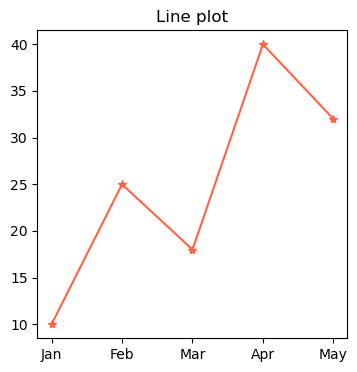

In [16]:
월 = ['Jan', 'Feb', 'Mar', 'Apr', 'May']
수치 = [10,25,18,40,32]
확인 = [80,200,150,350,310]
점유율 = [15,30,20,10,25]
점수 = [70,75,72,85,90,78,82,88,95,73]

#선그래프 그리기
#figure : 도화지를 불러왔다
#figsize : 도화지에 그릴 그림의 크기 / 15,10 픽셀 사이즈
plt.figure(figsize= (4,4))
plt.plot(월,수치, marker = '*', color = 'tomato')
plt.title('Line plot')
plt.show()

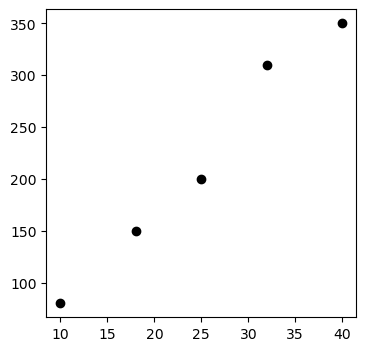

In [15]:
# 산점도
plt.figure(figsize=(4,4))
plt.scatter(수치, 확인, color='k')
plt.show()

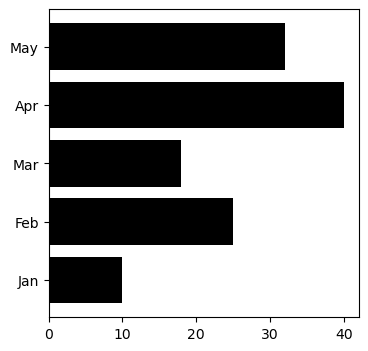

In [19]:
# 막대그래프
plt.figure(figsize = (4,4))
plt.barh(월,수치,color='black')
plt.show()

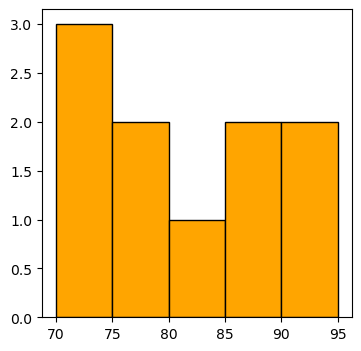

In [24]:
# 히스토그램
plt.figure(figsize=(4,4))
plt.hist(점수,
         bins = 5,
         color = 'orange', 
         edgecolor = 'black')
plt.show()

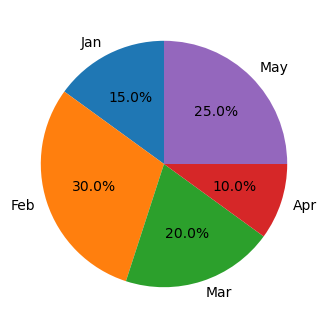

In [31]:
# 파이그래프
plt.figure(figsize=(4,4))
plt.pie(점유율,labels = 월, autopct = '%1.1f%%', startangle= 90)
plt.show()

In [60]:
df.groupby('Type 1')['Attack'].mean()

Type 1
Bug          70.971014
Dark         88.387097
Dragon      112.125000
Electric     69.090909
Fairy        61.529412
Fighting     96.777778
Fire         84.769231
Flying       78.750000
Ghost        73.781250
Grass        73.214286
Ground       95.750000
Ice          72.750000
Normal       73.469388
Poison       74.678571
Psychic      71.456140
Rock         92.863636
Steel        92.703704
Water        74.151786
Name: Attack, dtype: float64

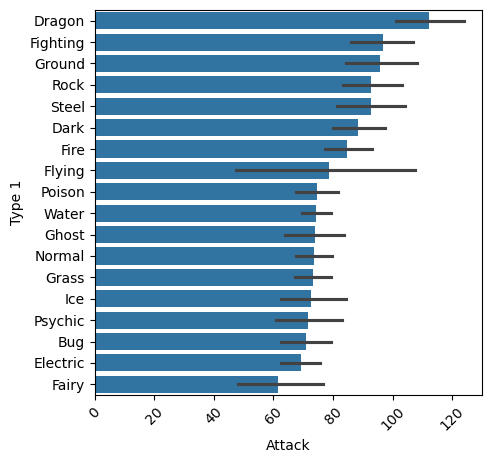

In [81]:
#5-0 #5. Type1별로 공격력의 평균치를 계산하여 막대그래프를 그려라

plt.figure(figsize=(5,5))
#공격격 평균 순서대로 정렬
type_order = df.groupby('Type 1')['Attack'].mean().sort_values(ascending = False).index #타입이 버그가 있었고 그런의미

sns.barplot(data = df, x = 'Attack', y = 'Type 1', order = type_order)
plt.xticks(rotation = 45)
plt.show()

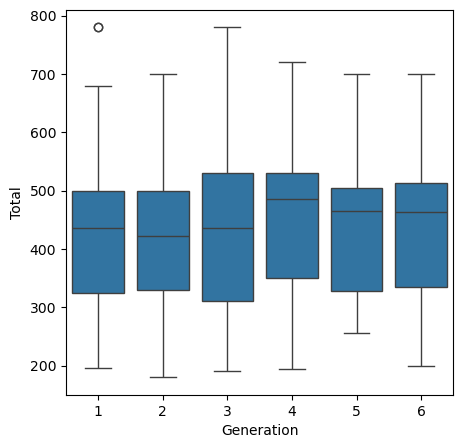

In [80]:
#4. 세대별로 총점의 분포가 어떻게 다른지 한눈에 비교할 수 있는 박스플롯을 그려라

plt.figure(figsize = (5,5))
sns.boxplot(data = df, x = 'Generation', y = 'Total')
plt.show()

#아래부터 최댓값, 1사분위, 2사분위, 3사분위, 최대값, o=이상치 --> 정규화 표준화

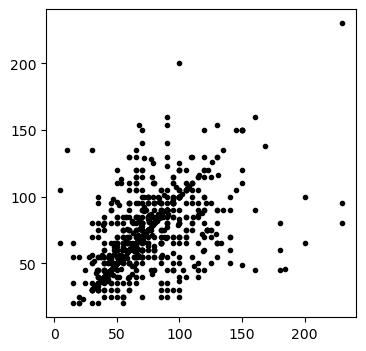

In [72]:
#3. 포켓몬의 방어력을 x축 특수방어력을 Y축으로 하는 산점도
방어력 = df['Defense']
특수방어력 = df['Sp. Def']
plt.figure(figsize=(4,4))
plt.scatter(방어력, 특수방어력, color='k', marker = '.')
plt.show()

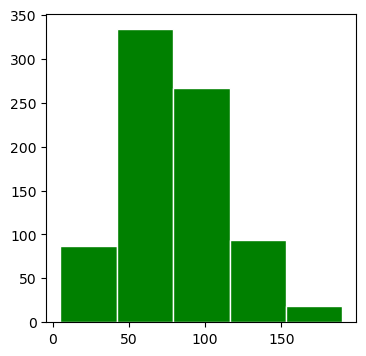

In [66]:
#2. 모든 포켓몬의 공격력 수치가 어떻게 분포되어있는지 히스토그램으로 그려라
공격력=df['Attack']
plt.figure(figsize=(4,4))
plt.hist(공격력, bins=5, color='green', edgecolor='white')
plt.show()

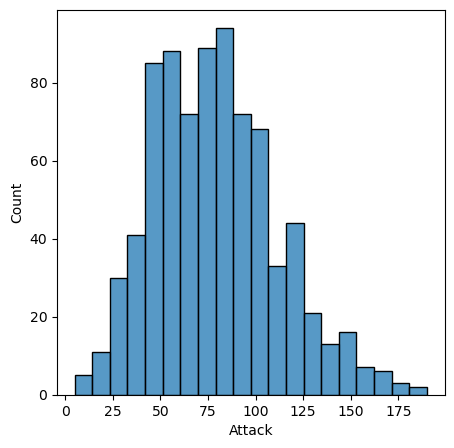

In [69]:
#2-0
plt.figure(figsize=(5,5))
sns.histplot(df['Attack'],bins=20)
plt.show()

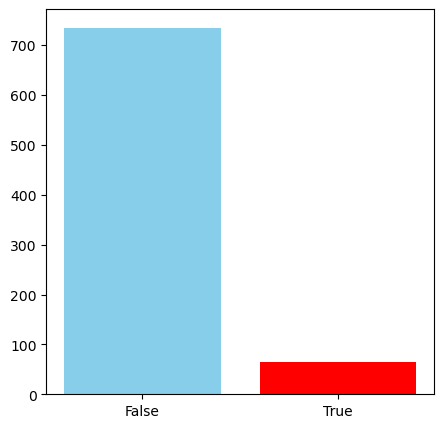

In [57]:
#1. 레전더리 컬럼을 사용하여 전설의 포켓몬과 일번포켓몬이 각각몇마리인지 나타내라

plt.figure(figsize = (5,5))
# 데이터를 카운트하는 내용 하나 만들어야 한다.
counts = df['Legendary'].value_counts()

plt.bar(counts.index.astype(str),counts.values,color = ['skyblue','red'])
plt.show()

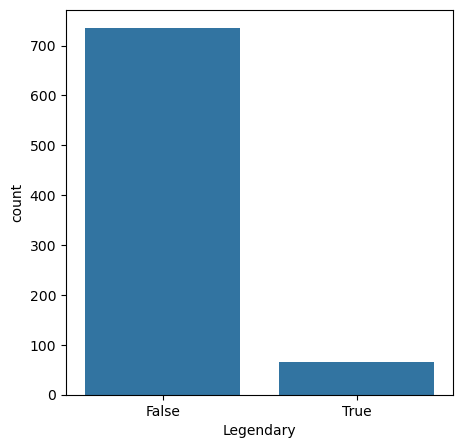

In [58]:
#1-1
plt.figure(figsize = (5,5))
sns.countplot(data = df, x = "Legendary")
plt.show()

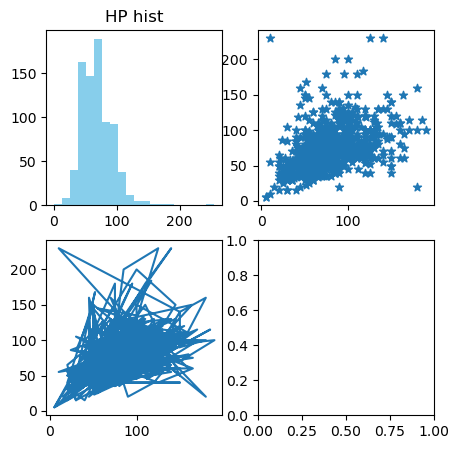

In [87]:
fig, ax = plt.subplots(2,2, figsize = (5,5))   #ax가 위치값을 할당받음
ax[0,0].hist(df['HP'], bins = 20, color = 'skyblue')
ax[0,0].set_title('HP hist')

ax[0,1].scatter(df['Attack'], df['Defense'],marker = '*')

ax[1,0].plot(df['Attack'], df['Defense'])

#  히트맵 그리기

In [89]:
df.info

<bound method DataFrame.info of        #                   Name   Type 1  Type 2  Total  HP  Attack  Defense  \
0      1              Bulbasaur    Grass  Poison    318  45      49       49   
1      2                Ivysaur    Grass  Poison    405  60      62       63   
2      3               Venusaur    Grass  Poison    525  80      82       83   
3      3  VenusaurMega Venusaur    Grass  Poison    625  80     100      123   
4      4             Charmander     Fire     NaN    309  39      52       43   
..   ...                    ...      ...     ...    ...  ..     ...      ...   
795  719                Diancie     Rock   Fairy    600  50     100      150   
796  719    DiancieMega Diancie     Rock   Fairy    700  50     160      110   
797  720    HoopaHoopa Confined  Psychic   Ghost    600  80     110       60   
798  720     HoopaHoopa Unbound  Psychic    Dark    680  80     160       60   
799  721              Volcanion     Fire   Water    600  80     110      120   

     Sp

In [107]:

수치_df = df[[ 'Total',  'HP',  'Attack' , 'Defense','Sp. Atk',  'Sp. Def',  'Speed' ]]

In [102]:
corr_ = 수치_df.corr()

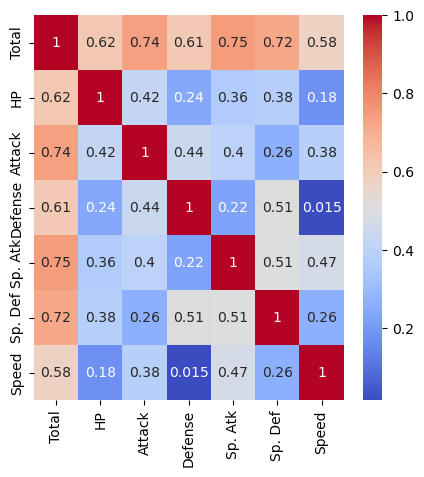

In [103]:
plt.figure(figsize=(5,5))
sns.heatmap(corr_, annot = True, cmap = 'coolwarm')
plt.show()

### 스택형 막대 그래프

- 하나의 막대 안에 여러 정보를 담고 싶을 때

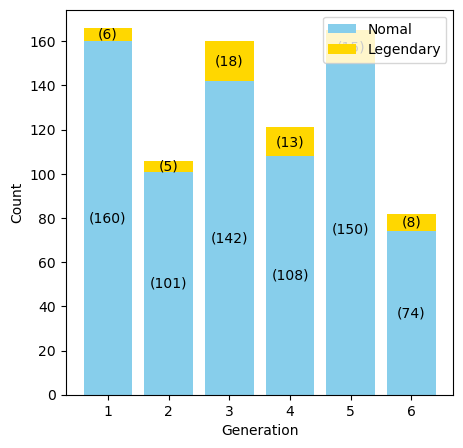

In [121]:
# 세대별 전설의 포케몬의 비중을 쌓아보자
st_data = df.groupby(['Generation','Legendary']).size().unstack().fillna(0)

# plt.bar(st_data.index.astype(str), st_data[False], label = 'Nomal', color = 'skyblue')
# plt.bar(st_data.index.astype(str), st_data[True], label = 'Legendary', color = 'gold')

plt.figure(figsize = (5,5))
bar_normal = plt.bar(st_data.index.astype(str), st_data[False], label = 'Nomal', color = 'skyblue')
bar_legendary = plt.bar(st_data.index.astype(str), st_data[True], bottom = st_data[False], label = 'Legendary', color = 'gold')

# 일반 포켓몬 수치 표시
for bar in bar_normal:
    height = bar.get_height()
    if height > 0:
        plt.text(bar.get_x() + bar.get_width()/2, height/2, f'({int(height)})', ha = 'center', va = 'center' )

#전설의포켓몬
for i, bar in enumerate(bar_legendary):
    height = bar.get_height()
    bottom_height = st_data[False].iloc[i]
    if height > 0:
        plt.text(bar.get_x() + bar.get_width()/2, bottom_height + height/2, f'({int(height)})', ha = 'center', va = 'center' )

plt.xlabel('Generation')
plt.ylabel('Count')
plt.legend()
plt.show()